#**E-Commerce Conversion Prediction Challenge**

## ***Step 1: Import Libraries***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

### Data Files Required

The notebook expects the following files in the working directory:

- train.csv
- public_test.csv
- private_test.csv

## ***Step 2: Load Data***

In [ ]:
train = pd.read_csv('/train.csv')
train.head()

,User_ID,Age,Income,City_Tier,Device_Type,Traffic_Source,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted
0,1,58.0,103593.70880,2,Mobile,Organic,5,4,9.61,3,0,11,2418,0
1,2,26.0,36451.71698,2,Mobile,Social Media,11,3,17.63,2,0,14,1213,0
2,3,19.0,30511.22870,3,Mobile,Referral,1,1,13.25,5,0,5,2849,0
3,4,48.0,87789.17234,3,Mobile,Email,14,12,NaN,1,1,19,7610,0
4,5,35.0,105229.24910,2,Mobile,Social Media,14,21,16.92,1,0,5,9261,0


In [ ]:
public_test = pd.read_csv('/public_test.csv')
public_test.head()

,User_ID,Age,Income,City_Tier,Device_Type,Traffic_Source,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted
0,100001,50.0,65922.413596,3,Tablet,Organic,15,16,NaN,2,0,13,5698,1
1,100002,39.0,43205.865640,1,Mobile,Paid Ads,17,16,12.72,2,1,10,7011,0
2,100003,NaN,44333.908253,3,Mobile,Organic,17,15,3.13,5,0,21,8265,1
3,100004,22.0,141906.816221,3,Desktop,Social Media,1,2,25.32,3,0,9,5592,0
4,100005,47.0,39521.673456,1,Mobile,Social Media,2,4,NaN,3,1,9,4128,0


In [ ]:
private_test = pd.read_csv('/private_test.csv')
private_test.head()

,User_ID,Age,Income,City_Tier,Device_Type,Traffic_Source,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code
0,103001,54.0,12000.000000,2,Mobile,Email,3,1,13.14,3,0,9,3685
1,103002,59.0,NaN,3,Mobile,Organic,22,20,NaN,4,0,18,9612
2,103003,NaN,79296.908337,2,Mobile,Paid Ads,28,24,3.36,1,0,2,4522
3,103004,19.0,65279.025663,2,Mobile,Social Media,20,13,8.78,6,1,5,4623
4,103005,31.0,NaN,3,Mobile,Paid Ads,10,15,24.14,5,0,20,8663


## ***Step 3 : EDA (Exploratory Data Analysis) and Data Preprocessing***

In [ ]:
print(train.shape)
print(public_test.shape)
print(private_test.shape)

(10000, 14)
(3000, 14)
(3000, 13)


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             10000 non-null  int64  
 1   Age                 8520 non-null   float64
 2   Income              9016 non-null   float64
 3   City_Tier           10000 non-null  int64  
 4   Device_Type         10000 non-null  object 
 5   Traffic_Source      10000 non-null  object 
 6   Pages_Viewed        10000 non-null  int64  
 7   Products_Viewed     10000 non-null  int64  
 8   Time_On_Site        8152 non-null   float64
 9   Previous_Purchases  10000 non-null  int64  
 10  Discount_Seen       10000 non-null  int64  
 11  Browser_Version     10000 non-null  int64  
 12  Campaign_Code       10000 non-null  int64  
 13  Converted           10000 non-null  int64  
dtypes: float64(3), int64(9), object(2)
memory usage: 1.1+ MB


***Handling Missing Values***

In [ ]:
missing_values_train = pd.DataFrame({
    "Missing Count": train.isnull().sum(),
    "Missing %": ((train.isnull().sum()/len(train))*100).round(2)
})

missing_values_train[missing_values_train["Missing Count"] > 0]

,Missing Count,Missing %
Age,1480,14.80
Income,984,9.84
Time_On_Site,1848,18.48


In [ ]:
missing_values_public = pd.DataFrame({
    "Missing Count": public_test.isnull().sum(),
    "Missing %": ((public_test.isnull().sum()/len(public_test))*100).round(2)
})

missing_values_public[missing_values_public["Missing Count"] > 0]

,Missing Count,Missing %
Age,472,15.73
Income,301,10.03
Time_On_Site,568,18.93


In [ ]:
missing_values_private = pd.DataFrame({
    "Missing Count": private_test.isnull().sum(),
    "Missing %": ((private_test.isnull().sum()/len(private_test))*100).round(2)
})

missing_values_private[missing_values_private["Missing Count"] > 0]

,Missing Count,Missing %
Age,461,15.37
Income,302,10.07
Time_On_Site,562,18.73


Missing values were observed only in the Age, Income, and Time_On_Site columns across all datasets. Since these are numerical features, median imputation can be used to handle missing values while minimizing the impact of outliers.

In [ ]:
missing_cols = ["Age", "Income", "Time_On_Site"]

imputer = SimpleImputer(strategy="median")

imputer.fit(train[missing_cols])

train[missing_cols] = imputer.transform(train[missing_cols])
public_test[missing_cols] = imputer.transform(public_test[missing_cols])
private_test[missing_cols] = imputer.transform(private_test[missing_cols])

In [ ]:
#Verifying
print(train.isnull().sum()[train.isnull().sum() > 0])
print(public_test.isnull().sum()[public_test.isnull().sum() > 0])
print(private_test.isnull().sum()[private_test.isnull().sum() > 0])

Series([], dtype: int64)
Series([], dtype: int64)
Series([], dtype: int64)


## ***Target Variable Analysis***

Here, we have the
**Numerical Features:**
- Age
- Income
- Pages_Viewed
- Products_Viewed
- Time_On_Site
- Previous_Purchases
- Browser_Version

**Categorical Features:**
- City_Tier
- Device_Type
- Traffic_Source
- Discount_Seen
- Campaign_Code

In [ ]:
#Creating a function for the Target Variable Analysis
def conversion_analysis(df, feature):

    result = (df.groupby(feature, observed=False)["Converted"].mean().mul(100).round(2))

    result.name = "Conversion Rate (%)"

    print(f"\nConversion Rate by {feature}")
    display(result)

    result.plot(kind="bar")

    plt.title(f"{feature} vs Conversion Rate")
    plt.xlabel(feature)
    plt.ylabel("Conversion Rate (%)")
    plt.xticks(rotation=0)
    plt.show()

## Age vs Target Variable

In [ ]:
train["Age"].describe()

,Age
count,10000.00000
mean,41.39000
std,12.71132
min,18.00000
25%,32.00000
50%,41.00000
75%,51.00000
max,65.00000


In [ ]:
#Dividing it into groups
train["Age_Group"] = pd.cut(
    train["Age"],
    bins=[0,25,40,50,100],
    labels=["<25","25-40","40-50","50+"])


Conversion Rate by Age_Group


,Conversion Rate (%)
Age_Group,
<25,32.17
25-40,30.04
40-50,31.22
50+,30.59


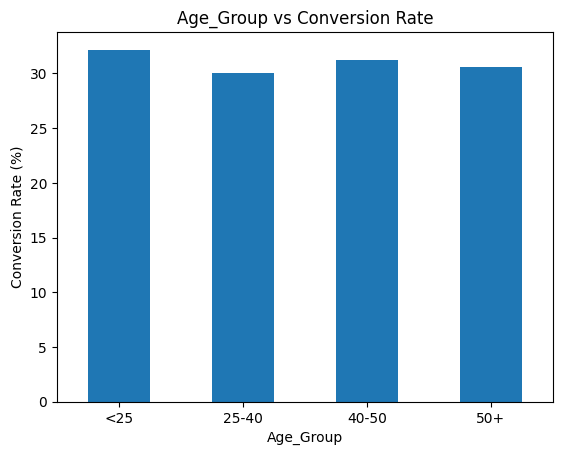

In [ ]:
conversion_analysis(train, "Age_Group")

Conversion Rate remains nearly constant for different age groups.

## Income vs Target Variable

In [ ]:
train["Income"].describe()

,Income
count,10000.000000
mean,69982.421139
std,23539.348771
min,12000.000000
25%,54638.953442
50%,70171.613670
75%,84886.015488
max,161687.774200


In [ ]:
train["Income_Group"] = pd.cut(
    train["Income"],
    bins=[12000, 55000, 70000, 85000, 165000],
    labels=["Low", "Lower-Middle", "Upper-Middle", "High"])


Conversion Rate by Income_Group


,Conversion Rate (%)
Income_Group,
Low,28.83
Lower-Middle,30.59
Upper-Middle,30.48
High,33.60


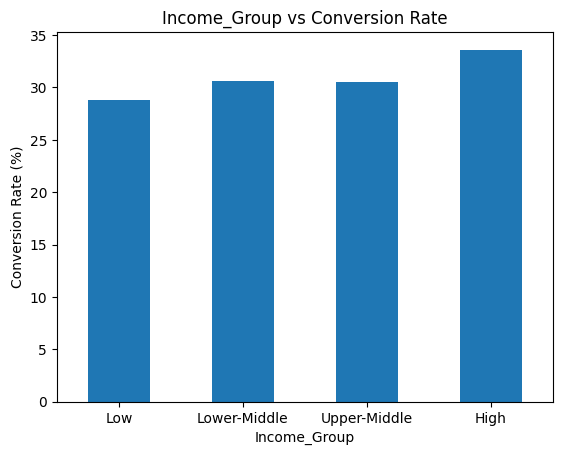

In [ ]:
conversion_analysis(train, "Income_Group")

Conversion rates generally increase with income levels, rising from approximately 29% for low-income users to 34% for high-income users

## City_Tier vs Target Variable


Conversion Rate by City_Tier


,Conversion Rate (%)
City_Tier,
1,30.30
2,32.03
3,29.42


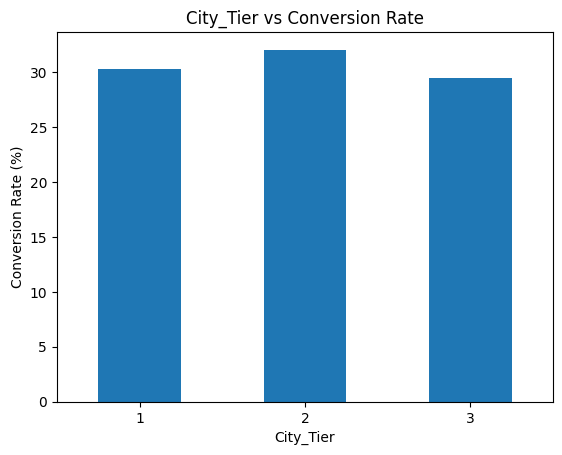

In [ ]:
conversion_analysis(train, "City_Tier")

Conversion rate remains nearly constant with City_Tier, with Tier 2 having the highest conversion rate (~32%)

## Device_Type vs Target Variable

In [ ]:
train["Device_Type"].value_counts()

,count
Device_Type,
Mobile,6523
Desktop,2472
Tablet,1005



Conversion Rate by Device_Type


,Conversion Rate (%)
Device_Type,
Desktop,33.09
Mobile,30.06
Tablet,30.65


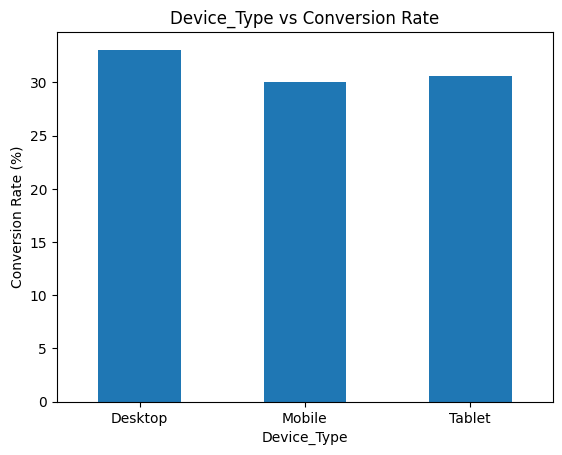

In [ ]:
conversion_analysis(train, "Device_Type")

Although Mobile devices account for the majority of website traffic (~65% of users), Desktop users demonstrate the highest conversion rate (33%). This indicates that while mobile drives larger volumes of traffic, desktop users may exhibit stronger purchase intent.

However, the overall differences across device types remain relatively small.

## Traffic_Source vs Target Variable


Conversion Rate by Traffic_Source


,Conversion Rate (%)
Traffic_Source,
Email,34.94
Organic,29.18
Paid Ads,27.71
Referral,38.12
Social Media,30.31


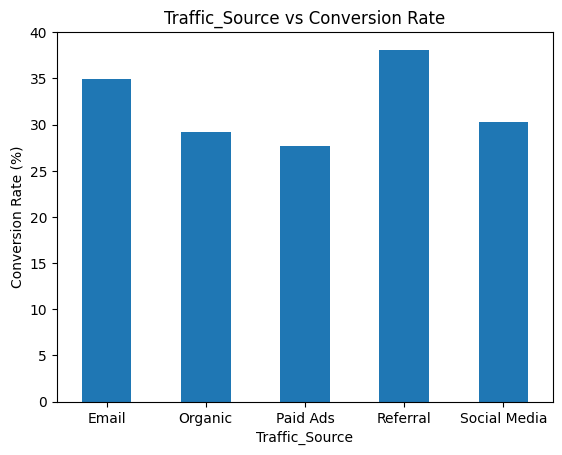

In [ ]:
conversion_analysis(train, "Traffic_Source")

In [ ]:
train["Traffic_Source"].value_counts()

,count
Traffic_Source,
Organic,3071
Paid Ads,2544
Social Media,1993
Referral,1456
Email,936


Referral (38%) and Email (35%) have the highest Conversion rates, and Paid ads (~28%) have the lowest Conversion rate

## Discount_Seen vs Target Variable


Conversion Rate by Discount_Seen


,Conversion Rate (%)
Discount_Seen,
0,25.52
1,35.42


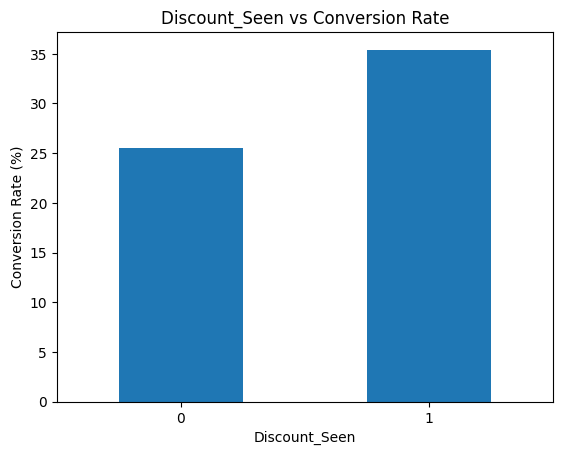

In [ ]:
conversion_analysis(train, "Discount_Seen") # 0 means did not see the discount and 1 means seen

Users who were shown a discount converted at a significantly higher rate (35.4%) than those who did not see a discount (25.5%).

## Previous_Purchases vs Target Variable

In [ ]:
train["Previous_Purchases"].describe()

,Previous_Purchases
count,10000.000000
mean,2.972500
std,1.738691
min,0.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,12.000000


In [ ]:
train["Previous_Purchases"].value_counts().sort_index()

,count
Previous_Purchases,
0,533
1,1540
2,2222
3,2207
4,1701
5,970
6,501
7,201
8,89


In [ ]:
train["Purchase_Group"] = pd.cut(
    train["Previous_Purchases"],
    bins=[-1, 0, 2, 5, 12],
    labels=["None", "Low", "Medium", "High"])


Conversion Rate by Purchase_Group


,Conversion Rate (%)
Purchase_Group,
None,23.64
Low,26.71
Medium,33.33
High,39.90


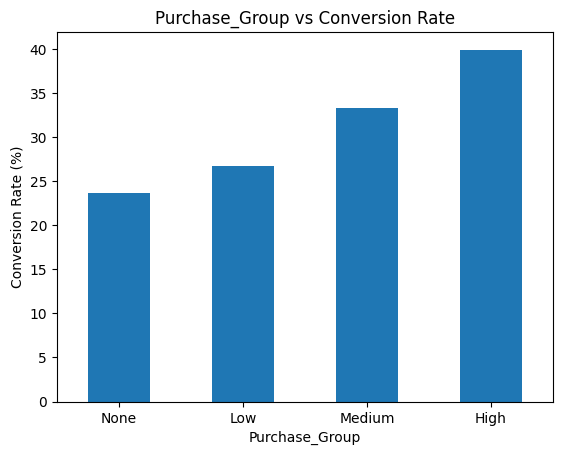

In [ ]:
conversion_analysis(train, "Purchase_Group")

Conversion rates increase consistently with purchase history. Users with no previous purchases exhibit the lowest conversion rate (~24%), while users with a high number of previous purchases convert at nearly 40%.

## Pages_Viewed vs Target Variable

In [ ]:
train["Pages_Viewed"].describe()

,Pages_Viewed
count,10000.00000
mean,15.60850
std,8.62346
min,1.00000
25%,8.00000
50%,16.00000
75%,23.00000
max,30.00000


In [ ]:
train["Pages_Group"] = pd.cut(
    train["Pages_Viewed"],
    bins=[0, 8, 16, 23, 30],
    labels=["Low", "Medium", "High", "Very High"])


Conversion Rate by Pages_Group


,Conversion Rate (%)
Pages_Group,
Low,13.29
Medium,24.43
High,37.10
Very High,51.36


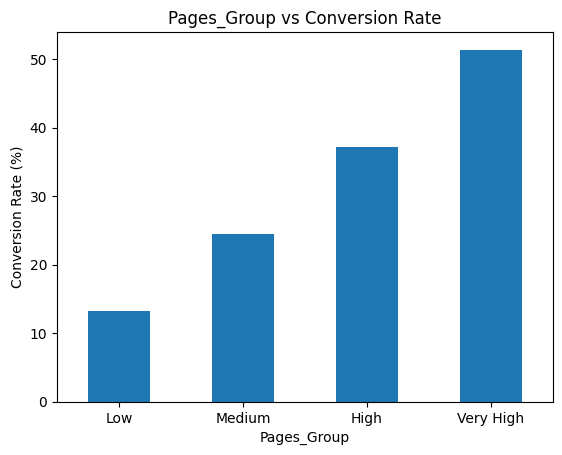

In [ ]:
conversion_analysis(train, "Pages_Group")

Conversion Rate shows a significant increase with more number of Pages_Viewed

## Products_Viewed vs Target Variable

In [ ]:
train["Products_Viewed"].describe()

,Products_Viewed
count,10000.000000
mean,15.219300
std,8.927563
min,1.000000
25%,8.000000
50%,15.000000
75%,23.000000
max,37.000000


In [ ]:
train["Products_Group"] = pd.cut(
    train["Products_Viewed"],
    bins=[0, 8, 15, 23, 40],
    labels=["Low", "Medium", "High", "Very High"])


Conversion Rate by Products_Group


,Conversion Rate (%)
Products_Group,
Low,13.24
Medium,25.01
High,37.79
Very High,51.07


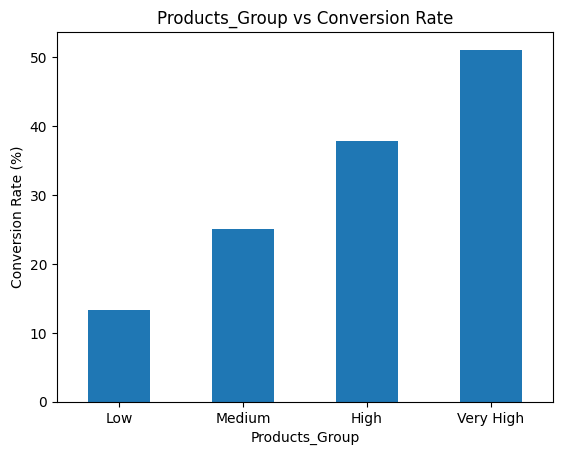

In [ ]:
conversion_analysis(train, "Products_Group")

Conversion Rate shows a significant increase with Products_Viewed

## Time_On_Site vs Target Variable

In [ ]:
train["Time_On_Site"].describe()

,Time_On_Site
count,10000.000000
mean,13.201131
std,17.577571
min,0.800000
25%,8.420000
50%,11.145000
75%,14.390000
max,607.390000


In [ ]:
train["Time_On_Site"].quantile([0.9, 0.95, 0.99])

,Time_On_Site
0.90,19.5200
0.95,23.1300
0.99,37.6404


In [ ]:
train["Time_Group"] = pd.qcut(
    train["Time_On_Site"],
    q=5,
    labels=["Very Low","Low","Medium","High","Very High"])


Conversion Rate by Time_Group


,Conversion Rate (%)
Time_Group,
Very Low,28.72
Low,30.33
Medium,24.80
High,33.50
Very High,37.00


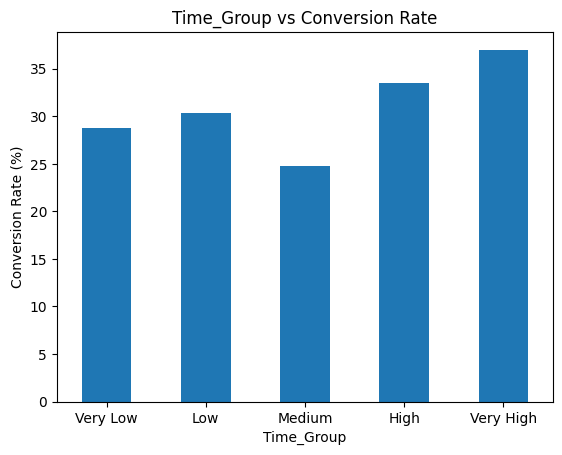

In [ ]:
conversion_analysis(train, "Time_Group")

Time_On_Site vs Conversion Rate remains nearly constant with the Medium group having the lowest and the Very High group having the highest Conversion Rate,

## Browser_Version and Campaign_Code vs Target Variable

In [ ]:
print("Browser Version:", train["Browser_Version"].nunique())
print("Campaign Code:", train["Campaign_Code"].nunique())

Browser Version: 24
Campaign Code: 6014



Conversion Rate by Browser_Version


,Conversion Rate (%)
Browser_Version,
1,30.16
2,29.00
3,28.61
4,30.70
5,32.49
6,38.37
7,30.02
8,29.09
9,31.44


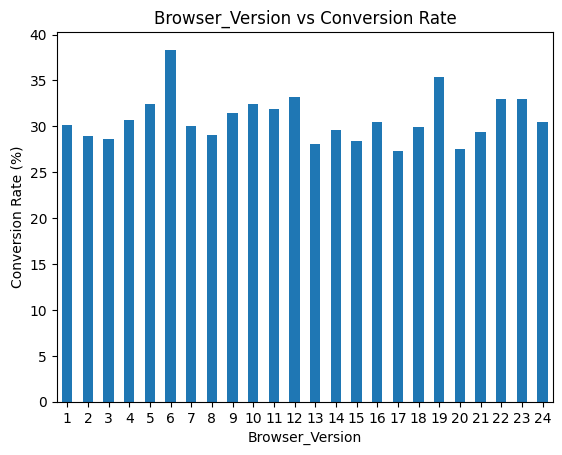

In [ ]:
conversion_analysis(train, "Browser_Version")

In [ ]:
train["Browser_Version"].value_counts().sort_index()

,count
Browser_Version,
1,378
2,431
3,416
4,469
5,357
6,443
7,423
8,416
9,404


Browser_Version doesn't show a significant effect on Conversion Rate

With over 6000 unique values, Campaign_Code contains substantial categorical diversity and will require appropriate encoding during modeling.

### Based on the EDA findings, user engagement metrics (*Pages_Viewed, Products_Viewed, Time_On_Site*), customer history (*Previous_Purchases*), and promotional exposure (*Discount_Seen*) are seen as the most influential predictors of conversion. onversion rates increase significantly with higher user engagement and purchase history, indicating that behavioral features play a major role in influencing purchase decisions.

### Among the *Traffic_Sources*, Referral has the highest conversion rate (38%), while Paid ads has the lowest (~28%). In contrast, demographic Factors like *Age*, *Income*, and *City_Tier* show relatively small differences in conversion rates and are therefore expected to have lower predictive importance compared to behavioral features.

## ***Step 4: Feature Engineering***

### *(1) Engagement Score (Combining Products_Viewed, Pages_Viewed, and Time_On_Site)*

In [ ]:
for df in [train, public_test, private_test]:
    df["Engagement_Score"] = (
        df["Pages_Viewed"] / train["Pages_Viewed"].max()
        + df["Products_Viewed"] / train["Products_Viewed"].max()
        + df["Time_On_Site"] / train["Time_On_Site"].max()
    )

### *(2) High Engagement Users and Discount Interaction*

In [ ]:
#defining high engagement score
Engagement_Median = train["Engagement_Score"].median()

for df in [train, public_test, private_test]:
    df["High_Engagement_Score"] = (df["Engagement_Score"] > Engagement_Median).astype(int)

In [ ]:
for df in [train, public_test, private_test]:
    df["High_Engagement_Discount"] = (df["High_Engagement_Score"] * df["Discount_Seen"])

### *(3) Discount_Seen* + *Returning_Customer*

In [ ]:
for df in [train, public_test, private_test]:
    df["Returning_Customer"] = (df["Previous_Purchases"] > 0).astype(int)

In [ ]:
for df in [train, public_test, private_test]:
    df["Discount_Returning"] = (df["Discount_Seen"] * df["Returning_Customer"])

### *(4) Time per Product*

In [ ]:
for df in [train, public_test, private_test]:
    df["Time_per_Product"] = (df["Time_On_Site"] / df["Products_Viewed"])

### *(5) Product Engagement*

In [ ]:
for df in [train, public_test, private_test]:
    df["Product_Engagement"] = (df["Products_Viewed"]* df["Time_On_Site"]) / df["Pages_Viewed"]

### *(6) Traffic_Source and Device_Type*

In [ ]:
for df in [train, public_test, private_test]:
    df["Source_Device"] = (df["Traffic_Source"].astype(str) + "_"+ df["Device_Type"].astype(str))

In [ ]:
#Verifying these features
engineered_features = [
    "Engagement_Score",
    "High_Engagement_Score",
    "High_Engagement_Discount",
    "Returning_Customer",
    "Discount_Returning",
    "Time_per_Product",
    "Product_Engagement",
    "Source_Device"
]

train[engineered_features].head()

,Engagement_Score,High_Engagement_Score,High_Engagement_Discount,Returning_Customer,Discount_Returning,Time_per_Product,Product_Engagement,Source_Device
0,0.290597,0,0,1,0,2.402500,7.688000,Organic_Mobile
1,0.476774,0,0,1,0,5.876667,4.808182,Social Media_Mobile
2,0.082175,0,0,1,0,13.250000,13.250000,Referral_Mobile
3,0.809340,0,0,1,1,0.928750,9.552857,Email_Mobile
4,1.062091,1,0,1,0,0.805714,25.380000,Social Media_Mobile


### **Feature Engineering Summary**

Based on insights obtained during Exploratory Data Analysis (EDA), several engineered features were created to better capture user behavior, engagement patterns, purchase history, discount responsiveness, and channel-device interactions.

The engineered features include:

* **Engagement_Score**: Overall user engagement based on pages viewed, products viewed, and time spent on the site.
* **High_Engagement_Score**: Identifies users with above-median engagement levels.
* **High_Engagement_Discount**: Captures the interaction between high engagement and discount exposure.
* **Returning_Customer**: Distinguishes returning customers from first-time visitors.
* **Discount_Returning**: Captures discount exposure among returning customers.
* **Time_per_Product**: Measures the average time spent evaluating each viewed product.
* **Product_Engagement**: Captures product-focused engagement behavior.
* **Source_Device**: Combines traffic source and device type to capture acquisition-channel interactions.

These engineered features are expected to provide stronger predictive signals than the raw features alone and improve the model's ability to identify potential conversions!


In [ ]:
#Checking Null Values
train[engineered_features].isnull().sum()

,0
Engagement_Score,0
High_Engagement_Score,0
High_Engagement_Discount,0
Returning_Customer,0
Discount_Returning,0
Time_per_Product,0
Product_Engagement,0
Source_Device,0


In [ ]:
#Checking infinite values
train[engineered_features].select_dtypes(include=np.number).replace([np.inf, -np.inf], np.nan).isnull().sum()

,0
Engagement_Score,0
High_Engagement_Score,0
High_Engagement_Discount,0
Returning_Customer,0
Discount_Returning,0
Time_per_Product,0
Product_Engagement,0


In [ ]:
#Verifying data type
train[engineered_features].dtypes

,0
Engagement_Score,float64
High_Engagement_Score,int64
High_Engagement_Discount,int64
Returning_Customer,int64
Discount_Returning,int64
Time_per_Product,float64
Product_Engagement,float64
Source_Device,object


## *Step 5: Classical Modelling*

### *5.1 Prepare Features and Target*

In [ ]:
TARGET = "Converted"

eda_cols = [
    "Age_Group",
    "Income_Group",
    "Purchase_Group",
    "Pages_Group",
    "Products_Group",
    "Time_Group"
]

X_train = train.drop(columns=[TARGET] + eda_cols)
y_train = train[TARGET]

X_public = public_test.drop(columns=[TARGET])
y_public = public_test[TARGET]

X_private = private_test.copy()

print(X_train.shape)
print(X_public.shape)
print(X_private.shape)

(10000, 21)
(3000, 21)
(3000, 21)


In [ ]:
categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical Features:", categorical_cols)
print("Number of Numerical Features:", len(numerical_cols))
print("Number of Categorical Features:", len(categorical_cols))

Categorical Features: ['Device_Type', 'Traffic_Source', 'Source_Device']
Number of Numerical Features: 18
Number of Categorical Features: 3


### *5.2 Building Preprocessing Pipeline*

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

### *5.3 Data Preprocessing*

Numerical features are standardized using StandardScaler, while categorical features are transformed using One-Hot Encoding. The preprocessing pipeline is fitted only on the training data and then applied to the public and private test sets to avoid data leakage.

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_public_processed = preprocessor.transform(X_public)

X_private_processed = preprocessor.transform(X_private)

print("Training Shape :", X_train_processed.shape)
print("Public Shape   :", X_public_processed.shape)
print("Private Shape  :", X_private_processed.shape)

Training Shape : (10000, 41)
Public Shape   : (3000, 41)
Private Shape  : (3000, 41)


### *5.4 Logistic Regression Model (Baseline)*

Logistic Regression is used as the baseline classification model. The model learns relationships between customer behaviour, demographic characteristics, traffic sources, and the engineered features to predict the probability of conversion.

In [ ]:
model_1 = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_1.fit(X_train_processed, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [ ]:
y_pred = model_1.predict(X_public_processed)

y_prob = model_1.predict_proba(X_public_processed)[:, 1]

In [ ]:
print("Accuracy :", accuracy_score(y_public, y_pred))
print("Precision:", precision_score(y_public, y_pred))
print("Recall   :", recall_score(y_public, y_pred))
print("F1 Score :", f1_score(y_public, y_pred))
print("ROC AUC  :", roc_auc_score(y_public, y_prob))

Accuracy : 0.727
Precision: 0.5784543325526932
Recall   : 0.27878103837471785
F1 Score : 0.37623762376237624
ROC AUC  : 0.730985091329223


The baseline Logistic Regression achieved an Accuracy of 72.7% and an ROC-AUC score of 0.731. However, the Recall (~27.9%) and F1 Score (0.376) were relatively low, indicating that the model missed a large proportion of actual converters!

In [ ]:
print(train["Converted"].value_counts())
print(train["Converted"].value_counts(normalize=True))

Converted
0    6913
1    3087
Name: count, dtype: int64
Converted
0    0.6913
1    0.3087
Name: proportion, dtype: float64


The target variable is moderately imbalanced, with approximately 69.1% non-converted users and 30.9% converted users. This imbalance can cause the model to favor the majority class, resulting in lower Recall for converted users.

### *5.5 Logistic Regression Model (Balanced)*



To address class imbalance, Logistic Regression was retrained using `class_weight="balanced"`.

This assigns a higher penalty to mistakes on the minority class (converted users), encouraging the model to identify more potential converters.

In [ ]:
model_2 = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

model_2.fit(X_train_processed, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
y_pred = model_2.predict(X_public_processed)

y_prob = model_2.predict_proba(X_public_processed)[:, 1]

In [ ]:
print("Accuracy :", accuracy_score(y_public, y_pred))
print("Precision:", precision_score(y_public, y_pred))
print("Recall   :", recall_score(y_public, y_pred))
print("F1 Score :", f1_score(y_public, y_pred))
print("ROC AUC  :", roc_auc_score(y_public, y_prob))

Accuracy : 0.683
Precision: 0.46993524514338575
Recall   : 0.5733634311512416
F1 Score : 0.5165226232841891
ROC AUC  : 0.7316439260140395


### *5.6 Comparing both types of Logistic Regression Model*

In [ ]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Baseline LR": [0.727, 0.578, 0.279, 0.376, 0.731],
    "Balanced LR": [0.683, 0.470, 0.573, 0.517, 0.732]
})

comparison.round(3)

,Metric,Baseline LR,Balanced LR
0,Accuracy,0.727,0.683
1,Precision,0.578,0.470
2,Recall,0.279,0.573
3,F1 Score,0.376,0.517
4,ROC-AUC,0.731,0.732


Although the baseline model achieved higher Accuracy, it struggled to identify actual converters, resulting in low Recall and F1 Score.
The balanced model improved Recall from 27.9% to 57.3% and increased the F1 Score from 0.376 to 0.517 while maintaining a similar value of ROC-AUC and Precision.

Since the objective is to effectively identify potential converters, therefore Balanced Logistic Regression model should be selected as the final model.

## *Step 6: Generating Final Predictions*

In [ ]:
final_predictions = model_2.predict(X_private_processed)
submission = pd.DataFrame({"User_ID": private_test["User_ID"],"Converted": final_predictions})

submission.head()

,User_ID,Converted
0,103001,0
1,103002,0
2,103003,0
3,103004,1
4,103005,0


In [ ]:
submission.to_csv("submission.csv", index=False)
print("submission.csv created successfully!")

submission.csv created successfully!


Now the submission.csv can be simply downloaded!